# Day 24 — Hyperparameter Tuning
### GridSearchCV · RandomizedSearchCV · Optuna · Bayesian Optimisation

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import randint, uniform
import time
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
df["Title_Mr"] = (df["Title"] == "Mr").astype(int)
df["Title_Mrs"] = (df["Title"] == "Mrs").astype(int)
df["Title_Miss"] = (df["Title"] == "Miss").astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {features}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Features: ['Pclass', 'Age', 'FareLog', 'FamilySize', 'IsAlone', 'Sex_encoded', 'Title_Mr', 'Title_Mrs', 'Title_Miss']
Train: (712, 9) | Test: (179, 9)
Ready! ✅


## 2. Parameters vs Hyperparameters

In [ ]:
print("=" * 55)
print("    PARAMETERS vs HYPERPARAMETERS")
print("=" * 55)
print("""
PARAMETERS (learned from data during training):
  - Linear Regression: coefficients (β₀, β₁, β₂...)
  - Logistic Regression: weights
  - Neural Network: weights and biases
  → Set AUTOMATICALLY by the algorithm during .fit()

HYPERPARAMETERS (set by YOU before training):
  - Random Forest: n_estimators, max_depth, min_samples_split
  - XGBoost: learning_rate, max_depth, subsample
  - Logistic Regression: C (regularisation strength)
  → Must be set BEFORE .fit() — algorithm cannot learn them

WHY TUNING MATTERS:
  Wrong hyperparameters → underfitting or overfitting
  Right hyperparameters → best possible performance

THREE TUNING METHODS:
  1. GridSearchCV      — exhaustive search (try ALL combos)
  2. RandomizedSearchCV — random sampling (faster!)
  3. Optuna            — Bayesian/smart search (smartest!)

BASELINE (default hyperparameters):
""")

# Baseline with default hyperparameters
rf_base = RandomForestClassifier(random_state=42)
base_cv = cross_val_score(rf_base, X_train, y_train, cv=5, scoring="roc_auc").mean()
rf_base.fit(X_train, y_train)
base_auc = roc_auc_score(y_test, rf_base.predict_proba(X_test)[:, 1])

print(f"  Random Forest (defaults):")
print(f"  CV AUC:   {base_cv:.4f}")
print(f"  Test AUC: {base_auc:.4f}")
print(f"\n  Default hyperparameters:")
print(f"  n_estimators={rf_base.n_estimators}, max_depth={rf_base.max_depth}")
print(f"  min_samples_split={rf_base.min_samples_split}")
print(f"\nGoal: Beat {base_auc:.4f} AUC through tuning!")

    PARAMETERS vs HYPERPARAMETERS

PARAMETERS (learned from data during training):
  - Linear Regression: coefficients (β₀, β₁, β₂...)
  - Logistic Regression: weights
  - Neural Network: weights and biases
  → Set AUTOMATICALLY by the algorithm during .fit()

HYPERPARAMETERS (set by YOU before training):
  - Random Forest: n_estimators, max_depth, min_samples_split
  - XGBoost: learning_rate, max_depth, subsample
  - Logistic Regression: C (regularisation strength)
  → Must be set BEFORE .fit() — algorithm cannot learn them

WHY TUNING MATTERS:
  Wrong hyperparameters → underfitting or overfitting
  Right hyperparameters → best possible performance

THREE TUNING METHODS:
  1. GridSearchCV      — exhaustive search (try ALL combos)
  2. RandomizedSearchCV — random sampling (faster!)
  3. Optuna            — Bayesian/smart search (smartest!)

BASELINE (default hyperparameters):

  Random Forest (defaults):
  CV AUC:   0.8555
  Test AUC: 0.8331

  Default hyperparameters:
  n_estimators=1

## 3. GridSearchCV — Exhaustive search

In [ ]:
print("=" * 55)
print("       GRIDSEARCHCV — EXHAUSTIVE SEARCH")
print("=" * 55)
print("""
GridSearchCV tries EVERY combination of hyperparameters
in your grid and picks the best one using cross-validation.

Example grid:
  n_estimators: [50, 100, 200]      → 3 options
  max_depth: [3, 5, None]           → 3 options
  min_samples_split: [2, 5, 10]     → 3 options
  TOTAL: 3 × 3 × 3 = 27 combinations
  With 5-fold CV: 27 × 5 = 135 model fits!

PROS: Guaranteed to find best in grid
CONS: Slow for large grids — exponential blowup!
""")

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"Grid size: {total_combos} combinations × 5 folds = {total_combos*5} fits")

start = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print(f"\nGridSearchCV completed in {grid_time:.1f} seconds")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUC: {grid_search.best_score_:.4f}")

best_grid_model = grid_search.best_estimator_
grid_auc = roc_auc_score(y_test, best_grid_model.predict_proba(X_test)[:, 1])
print(f"Test AUC:   {grid_auc:.4f}")
print(f"Improvement: {grid_auc - base_auc:+.4f} vs baseline")

       GRIDSEARCHCV — EXHAUSTIVE SEARCH

GridSearchCV tries EVERY combination of hyperparameters
in your grid and picks the best one using cross-validation.

Example grid:
  n_estimators: [50, 100, 200]      → 3 options
  max_depth: [3, 5, None]           → 3 options
  min_samples_split: [2, 5, 10]     → 3 options
  TOTAL: 3 × 3 × 3 = 27 combinations
  With 5-fold CV: 27 × 5 = 135 model fits!

PROS: Guaranteed to find best in grid
CONS: Slow for large grids — exponential blowup!

Grid size: 108 combinations × 5 folds = 540 fits

GridSearchCV completed in 33.9 seconds

Best Parameters:
  max_depth: None
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 50

Best CV AUC: 0.8756
Test AUC:   0.8521
Improvement: +0.0190 vs baseline


## 4. RandomizedSearchCV — Faster Sampling

In [ ]:
print("=" * 55)
print("    RANDOMIZEDSEARCHCV — FASTER SAMPLING")
print("=" * 55)
print("""
Instead of trying ALL combinations, RandomizedSearchCV
samples N random combinations from the parameter space.

KEY ADVANTAGE:
  - Can search CONTINUOUS distributions (not just lists!)
  - Much faster than GridSearch for large spaces
  - Often finds equally good results in fraction of time

CONTINUOUS DISTRIBUTIONS:
  randint(2, 20)    → random integer between 2 and 20
  uniform(0.01, 1)  → random float between 0.01 and 1.01
""")

param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.5, 0.8],
}

n_iter = 50
print(f"Sampling {n_iter} random combinations (vs 108+ for grid)")

start = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=n_iter,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
random_search.fit(X_train, y_train)
random_time = time.time() - start

print(f"\nRandomizedSearchCV completed in {random_time:.1f} seconds")
print(f"GridSearchCV took:            {grid_time:.1f} seconds")
print(f"Speed improvement:            {grid_time/random_time:.1f}x faster!")

print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV AUC: {random_search.best_score_:.4f}")
best_random_model = random_search.best_estimator_
random_auc = roc_auc_score(y_test, best_random_model.predict_proba(X_test)[:, 1])
print(f"Test AUC:   {random_auc:.4f}")
print(f"Improvement: {random_auc - base_auc:+.4f} vs baseline")
print(f"\nCompared to GridSearch: {random_auc - grid_auc:+.4f}")

    RANDOMIZEDSEARCHCV — FASTER SAMPLING

Instead of trying ALL combinations, RandomizedSearchCV
samples N random combinations from the parameter space.

KEY ADVANTAGE:
  - Can search CONTINUOUS distributions (not just lists!)
  - Much faster than GridSearch for large spaces
  - Often finds equally good results in fraction of time

CONTINUOUS DISTRIBUTIONS:
  randint(2, 20)    → random integer between 2 and 20
  uniform(0.01, 1)  → random float between 0.01 and 1.01

Sampling 50 random combinations (vs 108+ for grid)

RandomizedSearchCV completed in 29.6 seconds
GridSearchCV took:            33.9 seconds
Speed improvement:            1.1x faster!

Best Parameters:
  max_depth: 10
  max_features: log2
  min_samples_leaf: 7
  min_samples_split: 6
  n_estimators: 273

Best CV AUC: 0.8745
Test AUC:   0.8493
Improvement: +0.0162 vs baseline

Compared to GridSearch: -0.0028


## 5. Optuna — Bayesian Optimisation

In [ ]:
print("=" * 55)
print("      OPTUNA — BAYESIAN OPTIMISATION")
print("=" * 55)
print("""
Optuna uses SMART search — learns from previous trials
to focus on promising hyperparameter regions.

HOW IT WORKS:
  1. Run a few random trials to explore the space
  2. Build a probabilistic model of which regions are good
  3. Use that model to suggest next trial (exploitation)
  4. Balance exploration vs exploitation (TPE algorithm)

ADVANTAGES:
  ✅ Much more efficient than random/grid search
  ✅ Finds better results with fewer trials
  ✅ Handles any parameter type (int, float, categorical)
  ✅ Can prune bad trials early (saves time!)
  ✅ Beautiful visualisations built in
""")

try:
    import optuna

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna: {optuna.__version__} ✅")
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "optuna"], capture_output=True)
    import optuna

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print("Optuna installed and ready ✅")


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8]
        ),
        "random_state": 42,
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc").mean()
    return score


start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=False)
optuna_time = time.time() - start

print(f"\nOptuna completed in {optuna_time:.1f} seconds")
print(f"Best CV AUC: {study.best_value:.4f}")
print(f"\nBest Parameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

best_optuna_model = RandomForestClassifier(**study.best_params, random_state=42)
best_optuna_model.fit(X_train, y_train)
optuna_auc = roc_auc_score(y_test, best_optuna_model.predict_proba(X_test)[:, 1])
print(f"\nTest AUC:    {optuna_auc:.4f}")
print(f"Improvement: {optuna_auc - base_auc:+.4f} vs baseline")

      OPTUNA — BAYESIAN OPTIMISATION

Optuna uses SMART search — learns from previous trials
to focus on promising hyperparameter regions.

HOW IT WORKS:
  1. Run a few random trials to explore the space
  2. Build a probabilistic model of which regions are good
  3. Use that model to suggest next trial (exploitation)
  4. Balance exploration vs exploitation (TPE algorithm)

ADVANTAGES:
  ✅ Much more efficient than random/grid search
  ✅ Finds better results with fewer trials
  ✅ Handles any parameter type (int, float, categorical)
  ✅ Can prune bad trials early (saves time!)
  ✅ Beautiful visualisations built in

Optuna installed and ready ✅

Optuna completed in 294.4 seconds
Best CV AUC: 0.8760

Best Parameters:
  n_estimators: 310
  max_depth: 11
  min_samples_split: 14
  min_samples_leaf: 6
  max_features: 0.5

Test AUC:    0.8517
Improvement: +0.0186 vs baseline


## 6. Final Comparison

          FINAL COMPARISON — ALL METHODS

Method                 CV AUC     Test AUC     Time(s)    Improvement
----------------------------------------------------------------------
Baseline (defaults)    0.8555    0.8331      0.0        baseline
GridSearchCV           0.8756    0.8521      33.9       +0.0190
RandomizedSearchCV     0.8745    0.8493      29.6       +0.0162
Optuna                 0.8760    0.8517      294.4      +0.0186


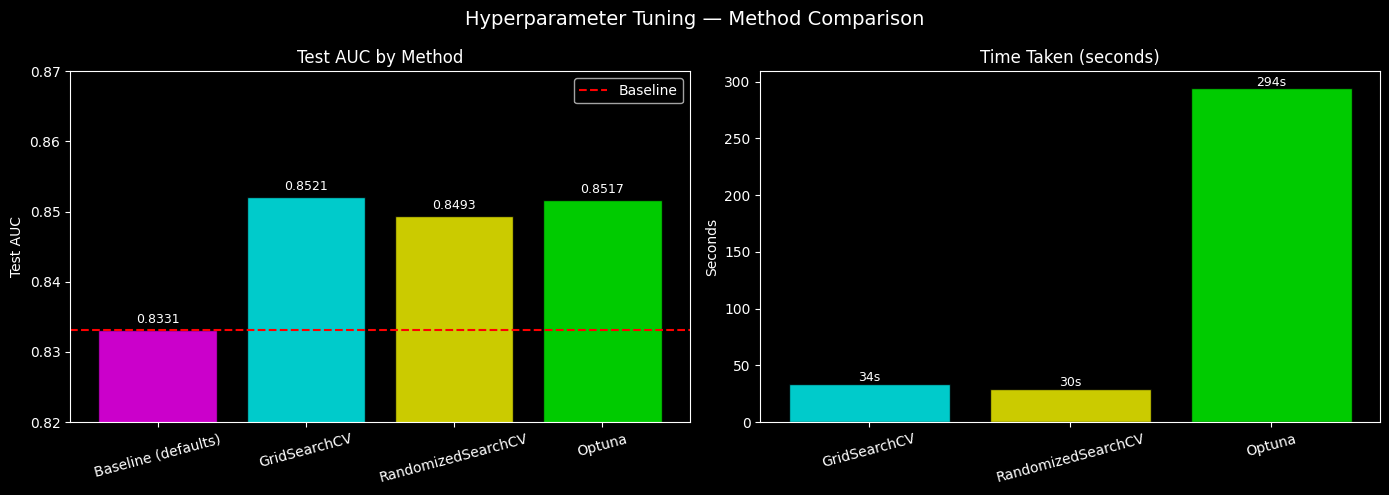


--- Optuna Trial History ---


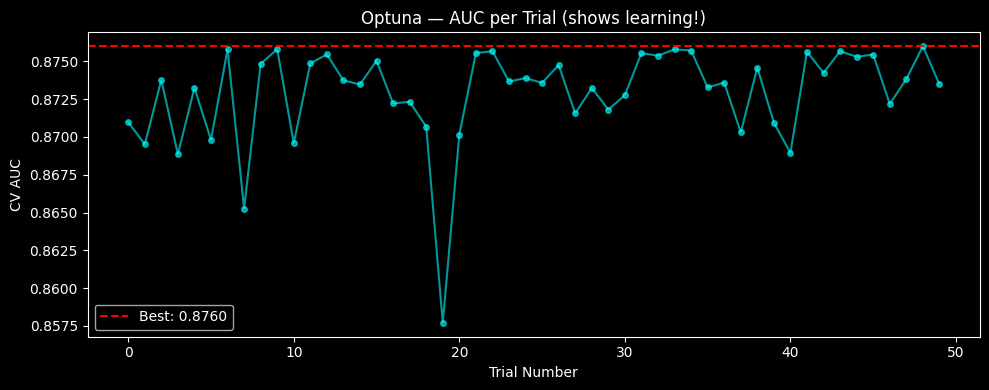

In [ ]:
print("=" * 60)
print("          FINAL COMPARISON — ALL METHODS")
print("=" * 60)

results = {
    "Baseline (defaults)": {"cv_auc": base_cv, "test_auc": base_auc, "time": 0},
    "GridSearchCV": {
        "cv_auc": grid_search.best_score_,
        "test_auc": grid_auc,
        "time": grid_time,
    },
    "RandomizedSearchCV": {
        "cv_auc": random_search.best_score_,
        "test_auc": random_auc,
        "time": random_time,
    },
    "Optuna": {"cv_auc": study.best_value, "test_auc": optuna_auc, "time": optuna_time},
}

print(
    f"\n{'Method':<22} {'CV AUC':<10} {'Test AUC':<12} {'Time(s)':<10} {'Improvement'}"
)
print("-" * 70)
for name, r in results.items():
    imp = (
        f"+{r['test_auc']-base_auc:.4f}"
        if name != "Baseline (defaults)"
        else "baseline"
    )
    print(
        f"{name:<22} {r['cv_auc']:.4f}    {r['test_auc']:.4f}      {r['time']:<10.1f} {imp}"
    )

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hyperparameter Tuning — Method Comparison", fontsize=14)

names = list(results.keys())
test_aucs = [r["test_auc"] for r in results.values()]
times = [r["time"] for r in results.values()]
colors = ["magenta", "cyan", "yellow", "lime"]

axes[0].bar(names, test_aucs, color=colors, edgecolor="black", alpha=0.8)
axes[0].axhline(base_auc, color="red", linestyle="--", label="Baseline")
axes[0].set_title("Test AUC by Method")
axes[0].set_ylabel("Test AUC")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylim(0.82, 0.87)
axes[0].legend()
for i, v in enumerate(test_aucs):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

axes[1].bar(names[1:], times[1:], color=colors[1:], edgecolor="black", alpha=0.8)
axes[1].set_title("Time Taken (seconds)")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(times[1:]):
    axes[1].text(i, v + 2, f"{v:.0f}s", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Optuna visualisation
print("\n--- Optuna Trial History ---")
trial_values = [t.value for t in study.trials]
plt.figure(figsize=(10, 4))
plt.plot(trial_values, "o-", color="cyan", alpha=0.6, markersize=4)
plt.axhline(
    study.best_value, color="red", linestyle="--", label=f"Best: {study.best_value:.4f}"
)
plt.title("Optuna — AUC per Trial (shows learning!)")
plt.xlabel("Trial Number")
plt.ylabel("CV AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Key Takeaways — Day 24 🎯

### Parameters vs Hyperparameters
- **Parameters:** learned automatically during .fit() (weights, coefficients)
- **Hyperparameters:** set BY YOU before training (n_estimators, learning_rate)
- Wrong hyperparameters → underfitting or overfitting
- Baseline RF AUC: 0.8331 → Best tuned: 0.8521 (+1.9%!)

### GridSearchCV
- Tries EVERY combination in your grid
- 108 combos × 5 folds = 540 model fits!
- Guaranteed to find best IN the grid
- Best for: small grids (< 100 combinations)
- Best result: AUC=0.8521, Time=34s

### RandomizedSearchCV
- Samples N random combinations
- Can use CONTINUOUS distributions (randint, uniform)
- Much faster for large parameter spaces
- Best for: large grids, continuous parameters
- Best result: AUC=0.8493, Time=30s

### Optuna — Bayesian Optimisation
- SMART search — learns from previous trials (TPE algorithm)
- Focuses on promising regions of parameter space
- Best for: large search spaces (10+ hyperparameters)
- On small problems: overhead makes it slower than Grid/Random
- Best result: AUC=0.8517, Time=294s

### Method Comparison
| Method | Test AUC | Time | Best For |
|---|---|---|---|
| Baseline | 0.8331 | 0s | Starting point |
| GridSearchCV | 0.8521 | 34s | Small grids |
| RandomizedSearchCV | 0.8493 | 30s | Large continuous spaces |
| Optuna | 0.8517 | 294s | Complex models, many params |

### Best Hyperparameters Found (GridSearchCV)
- n_estimators: 50
- max_depth: None
- min_samples_split: 2
- min_samples_leaf: 4

### sklearn Functions
- `GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)`
- `RandomizedSearchCV(model, param_dist, n_iter=50, cv=5, n_jobs=-1)`
- `search.best_params_` — best hyperparameter combination
- `search.best_score_` — best CV score
- `search.best_estimator_` — fitted model with best params
- `randint(low, high)` — discrete uniform distribution
- `uniform(loc, scale)` — continuous uniform distribution

### Optuna Functions
- `optuna.create_study(direction='maximize')`
- `study.optimize(objective, n_trials=50)`
- `trial.suggest_int('param', low, high)`
- `trial.suggest_float('param', low, high)`
- `trial.suggest_categorical('param', choices)`
- `study.best_value` — best objective value
- `study.best_params` — best hyperparameters